# Pandas & Data Wrangling — Notebook Completo

Este notebook organiza todo o projeto em formato `.ipynb`, reunindo os exemplos fundamentais de `NumPy` e `pandas` e a pipeline completa de data wrangling.

## O que você encontra aqui

- configuração do ambiente
- importação de bibliotecas
- definição de parâmetros e caminhos
- exemplos de `Series` e `DataFrame`
- leitura de `CSV`, `JSON` e `SQL`
- limpeza, agregação, `merge` e `reshape`
- séries temporais e visualização
- execução da pipeline final de wrangling
- validações simples e exportação de saídas

## 1. Configuração do Ambiente

Nesta etapa definimos caminhos, opções de exibição e preparamos o notebook para reutilizar os módulos do projeto.

In [1]:
# pyright: reportUnknownMemberType=false, reportArgumentType=false
from pathlib import Path
import sys

BASE_DIR = Path.cwd()
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

OUTPUT_DIR = BASE_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

BASE_DIR, OUTPUT_DIR

(WindowsPath('c:/GIT/PADILHA/pandas'),
 WindowsPath('c:/GIT/PADILHA/pandas/outputs'))

## 2. Importação de Bibliotecas

Aqui importamos apenas o que será usado ao longo do notebook, incluindo os módulos do projeto já criados em `src/pandas_wrangling_demo`.

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

from src.pandas_wrangling_demo.fundamentals import (
    build_cleaning_examples,
    build_dataframe_examples,
    build_groupby_examples,
    build_io_examples,
    build_merge_reshape_examples,
    build_numpy_examples,
    build_series_examples,
    build_time_series_examples,
    run_fundamentals_demo,
)
from src.pandas_wrangling_demo.pipeline import run_pipeline

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)
plt.style.use("ggplot")

## 3. Definição de Parâmetros e Entradas

Nesta seção centralizamos os caminhos e preparamos o diretório onde o notebook vai gravar artefatos.

In [3]:
NOTEBOOK_OUTPUT_DIR = OUTPUT_DIR / "notebook"
NOTEBOOK_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RAW_DATA_DIR = BASE_DIR / "data" / "raw"
RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)

config = {
    "base_dir": BASE_DIR,
    "raw_data_dir": RAW_DATA_DIR,
    "output_dir": OUTPUT_DIR,
    "notebook_output_dir": NOTEBOOK_OUTPUT_DIR,
}

config

{'base_dir': WindowsPath('c:/GIT/PADILHA/pandas'),
 'raw_data_dir': WindowsPath('c:/GIT/PADILHA/pandas/data/raw'),
 'output_dir': WindowsPath('c:/GIT/PADILHA/pandas/outputs'),
 'notebook_output_dir': WindowsPath('c:/GIT/PADILHA/pandas/outputs/notebook')}

## 4. Implementação Principal

As funções abaixo já existem no projeto. Aqui apenas executamos e organizamos o resultado em variáveis para análise passo a passo.

In [4]:
numpy_example = build_numpy_examples()
series_example = build_series_examples()
dataframe_example = build_dataframe_examples()
io_example = build_io_examples(NOTEBOOK_OUTPUT_DIR)
cleaning_example = build_cleaning_examples()
groupby_example = build_groupby_examples()
merge_reshape_example = build_merge_reshape_examples()
time_series_example = build_time_series_examples()

examples = {
    "numpy": numpy_example,
    "series": series_example,
    "dataframe": dataframe_example,
    "io": io_example,
    "cleaning": cleaning_example,
    "groupby": groupby_example,
    "merge_reshape": merge_reshape_example,
    "time_series": time_series_example,
}

list(examples.keys())

['numpy',
 'series',
 'dataframe',
 'io',
 'cleaning',
 'groupby',
 'merge_reshape',
 'time_series']

## 5. Execução de Exemplos

As células abaixo reproduzem os exemplos principais dos slides e mostram como os objetos evoluem no fluxo de análise.

In [5]:
print("NumPy -> média:", numpy_example["mean"])
print(pd.DataFrame({"array": numpy_example["array"]}).to_string(index=False))
print()
print(series_example["default"].to_string())
print()
print(series_example["labeled"].to_string())
print()
print("Valor do rótulo 'a':", series_example["value_a"])
print(series_example["positive"].to_string())
print()
print(dataframe_example["dataframe"].to_string(index=False))
print()
print(dataframe_example["estado_column"].to_string(index=False))
print()
print(dataframe_example["first_row_label"].to_string())
print()
print(dataframe_example["second_row_position"].to_string())

NumPy -> média: 2.25
 array
     4
     7
    -5
     3

0    4
1    7
2   -5
3    3

d    4
b    7
a   -5
c    3

Valor do rótulo 'a': -5
d    4
b    7
c    3

estado  ano  pop
    SP 2020 44.0
    SP 2021 44.5
    RJ 2021 17.4
    MG 2020 21.0

SP
SP
RJ
MG

estado      SP
ano       2020
pop       44.0

estado      SP
ano       2021
pop       44.5


In [6]:
print("Arquivos gerados na etapa de I/O:")
for path in io_example["files"]:
    print("-", path)

print("\nCSV")
print(io_example["csv"].to_string(index=False))

print("\nJSON")
print(io_example["json"].to_string(index=False))

print("\nSQL")
print(io_example["sql"].to_string(index=False))

print("\nAntes da limpeza")
print(cleaning_example["before"].to_string(index=False))
print("\nDepois da limpeza")
print(cleaning_example["after"].to_string(index=False))
print("Nulos antes:", cleaning_example["missing_before"])
print("Nulos depois:", cleaning_example["missing_after"])

print("\nDados de vendas")
print(groupby_example["sales"].to_string(index=False))
print("\nGroupBy")
print(groupby_example["grouped"].to_string(index=False))
print("\nPivot Table")
print(groupby_example["pivot"].to_string())

print("\nMerge")
print(merge_reshape_example["merged"].to_string(index=False))
print("\nMelt")
print(merge_reshape_example["melted"].to_string(index=False))
print("\nPivot")
print(merge_reshape_example["reshaped"].to_string())

print("\nSérie temporal diária")
print(time_series_example["daily"].to_string(index=False))
print("\nSérie temporal mensal")
print(time_series_example["monthly"].to_string(index=False))

Arquivos gerados na etapa de I/O:
- c:\GIT\PADILHA\pandas\outputs\notebook\students.csv
- c:\GIT\PADILHA\pandas\outputs\notebook\students.json
- c:\GIT\PADILHA\pandas\outputs\notebook\students.db

CSV
aluno  nota turma
  Ana   9.0     A
Bruno   7.5     A
Carla   8.8     B

JSON
aluno  nota turma
  Ana   9.0     A
Bruno   7.5     A
Carla   8.8     B

SQL
aluno  nota turma
  Ana   9.0     A
Bruno   7.5     A
Carla   8.8     B

Antes da limpeza
 produto preco  desconto   categoria
Notebook  3500      0.05 Eletronicos
   Mouse    80       NaN Eletronicos
   Mouse    80       NaN Eletronicos
Teclado    150      0.00 Eletronicos
     NaN   200      0.10  Acessorios

Depois da limpeza
     produto  preco  desconto   categoria  preco_final
    Notebook   3500      0.05 Eletronicos       3325.0
       Mouse     80      0.00 Eletronicos         80.0
     Teclado    150      0.00 Eletronicos        150.0
Desconhecido    200      0.10  Acessorios        180.0
Nulos antes: {'produto': 1, 'preco': 0

In [7]:
pipeline_result = run_pipeline(BASE_DIR)
pipeline_result

{'row_count': 10,
 'total_revenue': 12813.5,
 'output_dir': 'c:\\GIT\\PADILHA\\pandas\\outputs'}

## 6. Visualização dos Resultados

Aqui exibimos tabelas e gráficos produzidos pelas rotinas fundamentais e pela pipeline final.

Saídas da pipeline:
   category        region  total_orders  total_quantity  total_revenue
       Casa  Centro-Oeste             1               1          604.5
       Casa         Norte             1               3          360.0
Eletronicos       Sudeste             3               3         6800.0
Eletronicos Nao Informado             1               1         3264.0
Eletronicos      Nordeste             1               3          147.0
Eletronicos           Sul             1               2           80.0
     Moveis      Nordeste             1               1          810.0
     Moveis           Sul             1               2          748.0

       region  Corporativo  Enterprise  Varejo
 Centro-Oeste          0.0         0.0   604.5
Nao Informado          0.0      3264.0     0.0
     Nordeste        957.0         0.0     0.0
        Norte          0.0         0.0   360.0
      Sudeste       3475.0      3325.0     0.0
          Sul          0.0         0.0   828.0


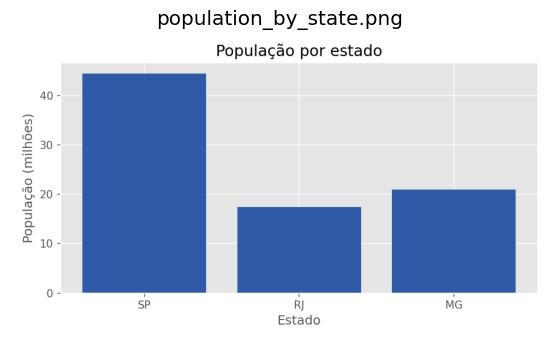

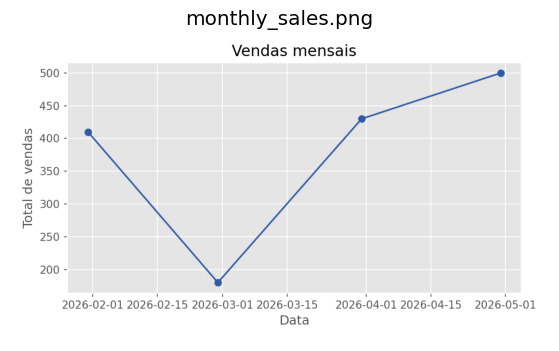

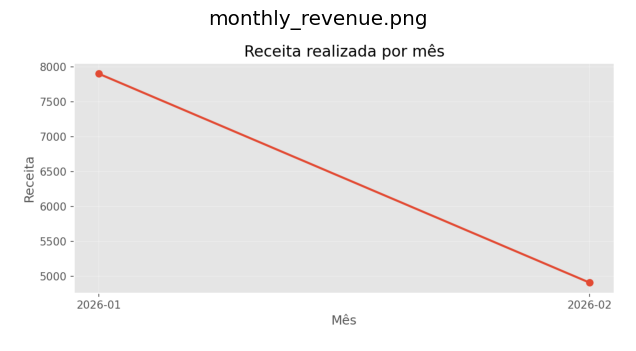

In [10]:
fundamentals_result = run_fundamentals_demo(BASE_DIR)
fundamentals_output_dir = Path(fundamentals_result["output_dir"])

sales_by_category = pd.read_csv(OUTPUT_DIR / "sales_by_category.csv")
sales_pivot = pd.read_csv(OUTPUT_DIR / "sales_pivot_region_segment.csv")

print("Saídas da pipeline:")
print(sales_by_category.to_string(index=False))
print()
print(sales_pivot.to_string(index=False))

for image_path in [
    fundamentals_output_dir / "population_by_state.png",
    fundamentals_output_dir / "monthly_sales.png",
    OUTPUT_DIR / "monthly_revenue.png",
]:
    image = plt.imread(image_path)
    plt.figure(figsize=(8, 4))
    plt.imshow(image)
    plt.axis("off")
    plt.title(image_path.name)
    plt.show()

## 7. Validação com Testes

Estas verificações rápidas confirmam que os exemplos essenciais e a pipeline estão produzindo os resultados esperados.

In [11]:
assert series_example["value_a"] == -5
assert series_example["positive"].to_dict() == {"d": 4, "b": 7, "c": 3}
assert dataframe_example["shape"] == (4, 3)
assert int(pipeline_result["row_count"]) == 10
assert float(pipeline_result["total_revenue"]) > 0
assert (OUTPUT_DIR / "sales_by_category.csv").exists()
assert (fundamentals_output_dir / "fundamentals_report.txt").exists()

print("Validações executadas com sucesso.")

Validações executadas com sucesso.


## 8. Exportação ou Salvamento da Saída

Por fim, consolidamos um resumo do notebook em disco para referência rápida.

In [12]:
summary_path = NOTEBOOK_OUTPUT_DIR / "notebook_summary.txt"
summary_text = "\n".join(
    [
        "Notebook Pandas & Data Wrangling",
        f"Base dir: {BASE_DIR}",
        f"Seções fundamentais: {', '.join(fundamentals_result['sections'])}",
        f"Row count pipeline: {pipeline_result['row_count']}",
        f"Receita total pipeline: {pipeline_result['total_revenue']:.2f}",
    ]
)
summary_path.write_text(summary_text, encoding="utf-8")
summary_path

WindowsPath('c:/GIT/PADILHA/pandas/outputs/notebook/notebook_summary.txt')

## 9. Streaming Avançado (CSV + JSONL + SQLite Temporário)

Nesta etapa aplicamos o modo de processamento por stream para reduzir uso de memória:

- leitura de `sales_*.csv` por chunks (`chunksize`)
- leitura de `customers.jsonl` por chunks
- agregações incrementais em SQLite temporário (incluindo contagem distinta de pedidos)

A API já está integrada em `run_pipeline(..., stream=True, chunk_size=...)`.

In [ ]:
default_run = run_pipeline(BASE_DIR, stream=False)
stream_run = run_pipeline(BASE_DIR, stream=True, chunk_size=2)

stream_summary = pd.DataFrame(
    [
        {"mode": "default", **default_run},
        {"mode": "stream", **stream_run},
    ]
)

print(stream_summary.to_string(index=False))

customers_jsonl_path = BASE_DIR / "data" / "raw" / "customers.jsonl"
temp_stream_db_path = OUTPUT_DIR / "stream_aggregate_temp.db"

print("customers.jsonl existe:", customers_jsonl_path.exists())
print("DB temporário limpo ao final:", not temp_stream_db_path.exists())

In [ ]:
assert int(default_run["row_count"]) == int(stream_run["row_count"])
assert abs(float(default_run["total_revenue"]) - float(stream_run["total_revenue"])) < 1e-9
assert customers_jsonl_path.exists()
assert not temp_stream_db_path.exists()

stream_sales_by_category = pd.read_csv(OUTPUT_DIR / "sales_by_category.csv")
stream_pivot = pd.read_csv(OUTPUT_DIR / "sales_pivot_region_segment.csv")

print("Validações de streaming OK.")
print("\nSales by category (stream):")
print(stream_sales_by_category.to_string(index=False))
print("\nPivot (stream):")
print(stream_pivot.to_string(index=False))

## 10. Benchmark Simples (Tempo e Memória)

Este benchmark rápido compara três estratégias de execução:

- modo padrão (`stream=False`)
- modo streaming sequencial (`stream=True`, `stream_workers=1`)
- modo streaming paralelo (`stream=True`, `stream_workers>1`)

> Observação: os números variam conforme máquina, carga do sistema e cache de disco. Use como referência relativa.


In [ ]:
import gc
import time
import tracemalloc


def benchmark_run(
    mode: str,
    *,
    stream: bool,
    chunk_size: int = 1000,
    workers: int = 1,
    in_flight: int = 0,
) -> dict[str, float | int | str]:
    gc.collect()
    tracemalloc.start()
    start = time.perf_counter()
    result = run_pipeline(
        BASE_DIR,
        stream=stream,
        chunk_size=chunk_size,
        stream_workers=workers,
        in_flight_tasks=in_flight,
    )
    elapsed = time.perf_counter() - start
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    return {
        "mode": mode,
        "elapsed_s": elapsed,
        "peak_mem_mb": peak / (1024 * 1024),
        "row_count": int(result["row_count"]),
        "total_revenue": float(result["total_revenue"]),
    }


benchmark_default = benchmark_run("default", stream=False)
benchmark_stream_seq = benchmark_run(
    "stream-sequential",
    stream=True,
    chunk_size=2,
    workers=1,
    in_flight=0,
)
benchmark_stream_threaded = benchmark_run(
    "stream-threaded",
    stream=True,
    chunk_size=2,
    workers=4,
    in_flight=8,
)

benchmark_df = pd.DataFrame([benchmark_default, benchmark_stream_seq, benchmark_stream_threaded])
benchmark_df["elapsed_s"] = benchmark_df["elapsed_s"].round(4)
benchmark_df["peak_mem_mb"] = benchmark_df["peak_mem_mb"].round(2)
benchmark_df["total_revenue"] = benchmark_df["total_revenue"].round(2)

assert benchmark_df["row_count"].nunique() == 1
assert benchmark_df["total_revenue"].nunique() == 1

print("Benchmark concluído.")
print(benchmark_df.to_string(index=False))


## 11. Benchmark com Múltiplas Repetições

Esta versão reduz ruído de medição rodando várias iterações por modo e calculando:

- média de tempo
- desvio padrão de tempo
- média de pico de memória
- desvio padrão de pico de memória

Modos comparados: `default`, `stream-sequential` e `stream-threaded`.


In [ ]:
import statistics as stats


def benchmark_many(
    mode: str,
    *,
    stream: bool,
    runs: int = 5,
    chunk_size: int = 2,
    workers: int = 1,
    in_flight: int = 0,
) -> list[dict[str, float | int | str]]:
    records: list[dict[str, float | int | str]] = []
    for run_idx in range(1, runs + 1):
        result = benchmark_run(
            mode,
            stream=stream,
            chunk_size=chunk_size,
            workers=workers,
            in_flight=in_flight,
        )
        result["run"] = run_idx
        records.append(result)
    return records


runs = 5
benchmark_configs = [
    {"mode": "default", "stream": False, "chunk_size": 1000, "workers": 1, "in_flight": 0},
    {"mode": "stream-sequential", "stream": True, "chunk_size": 2, "workers": 1, "in_flight": 0},
    {"mode": "stream-threaded", "stream": True, "chunk_size": 2, "workers": 4, "in_flight": 8},
]

raw_all: list[dict[str, float | int | str]] = []
for cfg in benchmark_configs:
    raw_all.extend(
        benchmark_many(
            cfg["mode"],
            stream=bool(cfg["stream"]),
            runs=runs,
            chunk_size=int(cfg["chunk_size"]),
            workers=int(cfg["workers"]),
            in_flight=int(cfg["in_flight"]),
        )
    )

raw_df = pd.DataFrame(raw_all)

summary_rows = []
for mode, group in raw_df.groupby("mode"):
    elapsed_values = group["elapsed_s"].tolist()
    memory_values = group["peak_mem_mb"].tolist()
    summary_rows.append(
        {
            "mode": mode,
            "runs": len(group),
            "elapsed_mean_s": stats.mean(elapsed_values),
            "elapsed_std_s": stats.pstdev(elapsed_values),
            "peak_mem_mean_mb": stats.mean(memory_values),
            "peak_mem_std_mb": stats.pstdev(memory_values),
            "row_count": int(group["row_count"].iloc[0]),
            "total_revenue": float(group["total_revenue"].iloc[0]),
        }
    )

summary_df = pd.DataFrame(summary_rows).sort_values("mode")
summary_df["elapsed_mean_s"] = summary_df["elapsed_mean_s"].round(4)
summary_df["elapsed_std_s"] = summary_df["elapsed_std_s"].round(4)
summary_df["peak_mem_mean_mb"] = summary_df["peak_mem_mean_mb"].round(2)
summary_df["peak_mem_std_mb"] = summary_df["peak_mem_std_mb"].round(2)
summary_df["total_revenue"] = summary_df["total_revenue"].round(2)

assert summary_df["row_count"].nunique() == 1
assert summary_df["total_revenue"].nunique() == 1

print("Medições brutas por execução:")
print(raw_df.to_string(index=False))
print("\nResumo estatístico:")
print(summary_df.to_string(index=False))


## 12. Gráficos Comparativos dos Benchmarks

Os gráficos abaixo resumem tempo e memória entre os três modos.
O segundo gráfico usa as médias da seção de múltiplas repetições (`summary_df`).


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_df = benchmark_df.sort_values("mode")
axes[0].bar(plot_df["mode"], plot_df["elapsed_s"], color=["#4C78A8", "#72B7B2", "#F58518"])
axes[0].set_title("Tempo por modo (execução única)")
axes[0].set_ylabel("Tempo (s)")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(plot_df["mode"], plot_df["peak_mem_mb"], color=["#4C78A8", "#72B7B2", "#F58518"])
axes[1].set_title("Memória de pico por modo (execução única)")
axes[1].set_ylabel("Memória (MB)")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

avg_df = summary_df.sort_values("mode")
axes[0].bar(avg_df["mode"], avg_df["elapsed_mean_s"], yerr=avg_df["elapsed_std_s"], capsize=4, color=["#54A24B", "#EECA3B", "#E45756"])
axes[0].set_title("Tempo médio por modo (múltiplas repetições)")
axes[0].set_ylabel("Tempo médio (s)")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(avg_df["mode"], avg_df["peak_mem_mean_mb"], yerr=avg_df["peak_mem_std_mb"], capsize=4, color=["#54A24B", "#EECA3B", "#E45756"])
axes[1].set_title("Memória média por modo (múltiplas repetições)")
axes[1].set_ylabel("Memória média (MB)")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()
